#Import

In [34]:
#Menginstall library yang digunakan untuk mengimport data ke SQL
!pip install sqlalchemy psycopg2-binary

In [35]:
#Mengimport library yang digunakan untuk analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

#Connect to SQL

In [36]:
#Memasukkan informasi yang dibutuhkan untuk mengimport data ke SQL
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres.wrprbwghsiweangcbxmb"
password = quote_plus("Dedew123!@Tri")
host = "aws-1-ap-southeast-2.pooler.supabase.com"
port = "6543"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

#Actor

In [37]:
#Menampilkan data yang sudah di-upload di github
df1 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/actor_202605261428.csv")

##Read Data

In [38]:
df1

,actor_id,first_name,last_name,last_update
0,1,PENELOPE,GUINESS,2006-02-15 04:34:33.000
1,2,NICK,WAHLBERG,2006-02-15 04:34:33.000
2,3,ED,CHASE,2006-02-15 04:34:33.000
3,4,JENNIFER,DAVIS,2006-02-15 04:34:33.000
4,5,JOHNNY,LOLLOBRIGIDA,2006-02-15 04:34:33.000
...,...,...,...,...
195,196,BELA,WALKEN,2006-02-15 04:34:33.000
196,197,REESE,WEST,2006-02-15 04:34:33.000
197,198,MARY,KEITEL,2006-02-15 04:34:33.000
198,199,JULIA,FAWCETT,2006-02-15 04:34:33.000


##Hapus Kolom Last Update

In [39]:
df1 = df1.drop(columns=['last_update'])

In [40]:
df1

,actor_id,first_name,last_name
0,1,PENELOPE,GUINESS
1,2,NICK,WAHLBERG
2,3,ED,CHASE
3,4,JENNIFER,DAVIS
4,5,JOHNNY,LOLLOBRIGIDA
...,...,...,...
195,196,BELA,WALKEN
196,197,REESE,WEST
197,198,MARY,KEITEL
198,199,JULIA,FAWCETT


##Tipe Data

In [41]:
#Menampilkan tipe data tiap kolom
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   actor_id    200 non-null    int64 
 1   first_name  200 non-null    object
 2   last_name   200 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


##Statistika Dasar

In [42]:
df1.describe()

,actor_id
count,200.000000
mean,100.500000
std,57.879185
min,1.000000
25%,50.750000
50%,100.500000
75%,150.250000
max,200.000000


##Data Missing Value

In [43]:
#Menampilkan data yang kosong
df1.isnull().sum()

,0
actor_id,0
first_name,0
last_name,0


##Data Duplikat

In [44]:
#Mengecek data apakah ada yang duplikat atau tidak
df1.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [45]:
#Mengimport data setelah di cleaning ke SQL
df1.to_sql('actor_clean', con=engine, schema='public', if_exists='replace', index=False)

200

#Address

##Read Data

In [46]:
#Menampilkan data yang sudah di-upload di github
df2 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/address_202605261429.csv")

In [47]:
df2

,address_id,address,address2,district,city_id,postal_code,phone,last_update
0,1,47 MySakila Drive,NaN,,300,NaN,,2006-02-15 04:45:30.000
1,2,28 MySQL Boulevard,NaN,,576,NaN,,2006-02-15 04:45:30.000
2,3,23 Workhaven Lane,NaN,,300,NaN,,2006-02-15 04:45:30.000
3,4,1411 Lillydale Drive,NaN,,576,NaN,,2006-02-15 04:45:30.000
4,5,1913 Hanoi Way,NaN,,463,35200.0,,2006-02-15 04:45:30.000
...,...,...,...,...,...,...,...,...
598,601,844 Bucuresti Place,NaN,,242,36603.0,,2006-02-15 04:45:30.000
599,602,1101 Bucuresti Boulevard,NaN,,401,97661.0,,2006-02-15 04:45:30.000
600,603,1103 Quilmes Boulevard,NaN,,503,52137.0,,2006-02-15 04:45:30.000
601,604,1331 Usak Boulevard,NaN,,296,61960.0,,2006-02-15 04:45:30.000


##Hapus Kolom District, Phone, dan Last Update

In [48]:
df2=df2.drop(columns=['district','phone','last_update'])

In [49]:
df2

,address_id,address,address2,city_id,postal_code
0,1,47 MySakila Drive,NaN,300,NaN
1,2,28 MySQL Boulevard,NaN,576,NaN
2,3,23 Workhaven Lane,NaN,300,NaN
3,4,1411 Lillydale Drive,NaN,576,NaN
4,5,1913 Hanoi Way,NaN,463,35200.0
...,...,...,...,...,...
598,601,844 Bucuresti Place,NaN,242,36603.0
599,602,1101 Bucuresti Boulevard,NaN,401,97661.0
600,603,1103 Quilmes Boulevard,NaN,503,52137.0
601,604,1331 Usak Boulevard,NaN,296,61960.0


##Tipe Data

In [50]:
#Menampilkan tipe data tiap kolom
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   address_id   603 non-null    int64  
 1   address      603 non-null    object 
 2   address2     0 non-null      float64
 3   city_id      603 non-null    int64  
 4   postal_code  599 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 23.7+ KB


##Statistika Dasar

In [51]:
df2.describe()

,address_id,address2,city_id,postal_code
count,603.000000,0.0,603.000000,599.000000
mean,302.719735,NaN,300.525705,50222.313856
std,174.853150,NaN,173.600949,28986.085055
min,1.000000,NaN,1.000000,3.000000
25%,151.500000,NaN,150.500000,25182.500000
50%,303.000000,NaN,300.000000,50805.000000
75%,453.500000,NaN,450.500000,74920.000000
max,605.000000,NaN,600.000000,99865.000000


##Data Missing Value

In [52]:
#Menampilkan data yang kosong
df2.isnull().sum()

,0
address_id,0
address,0
address2,603
city_id,0
postal_code,4


##Menghapus Kolom Address2

In [53]:
df2.drop(columns=['address2'],inplace=True)

##Menghapus Data Missing Value di Kolom Postal Code

In [54]:
df2.dropna(subset=['postal_code'], inplace=True)

In [55]:
df2

,address_id,address,city_id,postal_code
4,5,1913 Hanoi Way,463,35200.0
5,6,1121 Loja Avenue,449,17886.0
6,7,692 Joliet Street,38,83579.0
7,8,1566 Inegl Manor,349,53561.0
8,9,53 Idfu Parkway,361,42399.0
...,...,...,...,...
598,601,844 Bucuresti Place,242,36603.0
599,602,1101 Bucuresti Boulevard,401,97661.0
600,603,1103 Quilmes Boulevard,503,52137.0
601,604,1331 Usak Boulevard,296,61960.0


In [56]:
#Menampilkan data yang kosong
df2.isnull().sum()

,0
address_id,0
address,0
city_id,0
postal_code,0


##Ubah Tipe Data Kolom Postal Code

In [57]:
#Mengubah tipe data kolom "postal_code" yang awalnya float menjadi integer
df2['postal_code'] = df2['postal_code'].astype(int)

In [58]:
df2

,address_id,address,city_id,postal_code
4,5,1913 Hanoi Way,463,35200
5,6,1121 Loja Avenue,449,17886
6,7,692 Joliet Street,38,83579
7,8,1566 Inegl Manor,349,53561
8,9,53 Idfu Parkway,361,42399
...,...,...,...,...
598,601,844 Bucuresti Place,242,36603
599,602,1101 Bucuresti Boulevard,401,97661
600,603,1103 Quilmes Boulevard,503,52137
601,604,1331 Usak Boulevard,296,61960


##Data Duplikat

In [59]:
#Mengecek data apakah ada yang duplikat atau tidak
df2.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [60]:
#Mengimport data setelah di cleaning ke SQL
df2.to_sql('address_clean', con=engine, schema='public', if_exists='replace', index=False)

599

#Category

##Read Data

In [61]:
df3 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/category_202605261429.csv")

In [62]:
df3

,category_id,name,last_update
0,1,Action,2006-02-15 04:46:27.000
1,2,Animation,2006-02-15 04:46:27.000
2,3,Children,2006-02-15 04:46:27.000
3,4,Classics,2006-02-15 04:46:27.000
4,5,Comedy,2006-02-15 04:46:27.000
5,6,Documentary,2006-02-15 04:46:27.000
6,7,Drama,2006-02-15 04:46:27.000
7,8,Family,2006-02-15 04:46:27.000
8,9,Foreign,2006-02-15 04:46:27.000
9,10,Games,2006-02-15 04:46:27.000


##Hapus Kolom Last Update

In [63]:
df3 = df3.drop(columns=['last_update'])

In [64]:
df3

,category_id,name
0,1,Action
1,2,Animation
2,3,Children
3,4,Classics
4,5,Comedy
5,6,Documentary
6,7,Drama
7,8,Family
8,9,Foreign
9,10,Games


##Tipe Data

In [65]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category_id  16 non-null     int64 
 1   name         16 non-null     object
dtypes: int64(1), object(1)
memory usage: 388.0+ bytes


##Statistika Dasar

In [66]:
df3.describe()

,category_id
count,16.000000
mean,8.500000
std,4.760952
min,1.000000
25%,4.750000
50%,8.500000
75%,12.250000
max,16.000000


##Data Missing Value

In [67]:
#Menampilkan data yang kosong
df3.isnull().sum()

,0
category_id,0
name,0


##Duplikat Data

In [68]:
#Mengecek data apakah ada yang duplikat atau tidak
df3.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [69]:
#Mengimport data setelah di cleaning ke SQL
df3.to_sql('category_clean', con=engine, schema='public', if_exists='replace', index=False)

16

#City

##Read Data

In [70]:
df4 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/city_202605261429.csv")

In [71]:
df4

,city_id,city,country_id,last_update
0,1,A Corua (La Corua),87,2006-02-15 04:45:25.000
1,2,Abha,82,2006-02-15 04:45:25.000
2,3,Abu Dhabi,101,2006-02-15 04:45:25.000
3,4,Acua,60,2006-02-15 04:45:25.000
4,5,Adana,97,2006-02-15 04:45:25.000
...,...,...,...,...
595,596,Zaria,69,2006-02-15 04:45:25.000
596,597,Zeleznogorsk,80,2006-02-15 04:45:25.000
597,598,Zhezqazghan,51,2006-02-15 04:45:25.000
598,599,Zhoushan,23,2006-02-15 04:45:25.000


##Hapus Kolom Last Update

In [72]:
df4 = df4.drop(columns=['last_update'])

In [73]:
df4

,city_id,city,country_id
0,1,A Corua (La Corua),87
1,2,Abha,82
2,3,Abu Dhabi,101
3,4,Acua,60
4,5,Adana,97
...,...,...,...
595,596,Zaria,69
596,597,Zeleznogorsk,80
597,598,Zhezqazghan,51
598,599,Zhoushan,23


##Tipe Data

In [74]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   city_id     600 non-null    int64 
 1   city        600 non-null    object
 2   country_id  600 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 14.2+ KB


##Statistika Dasar

In [75]:
df4.describe()

,city_id,country_id
count,600.000000,600.000000
mean,300.500000,56.400000
std,173.349358,30.064594
min,1.000000,1.000000
25%,150.750000,28.750000
50%,300.500000,50.000000
75%,450.250000,80.000000
max,600.000000,109.000000


##Data Missing Value

In [76]:
#Menampilkan data yang kosong
df4.isnull().sum()

,0
city_id,0
city,0
country_id,0


##Data Duplikat

In [77]:
#Mengecek data apakah ada yang duplikat atau tidak
df4.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [78]:
#Mengimport data setelah di cleaning ke SQL
df4.to_sql('city_clean', con=engine, schema='public', if_exists='replace', index=False)

600

#Country

##Read Data

In [79]:
df5 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/country_202605261429.csv")

In [80]:
df5

,country_id,country,last_update
0,1,Afghanistan,2006-02-15 04:44:00.000
1,2,Algeria,2006-02-15 04:44:00.000
2,3,American Samoa,2006-02-15 04:44:00.000
3,4,Angola,2006-02-15 04:44:00.000
4,5,Anguilla,2006-02-15 04:44:00.000
...,...,...,...
104,105,Vietnam,2006-02-15 04:44:00.000
105,106,"Virgin Islands, U.S.",2006-02-15 04:44:00.000
106,107,Yemen,2006-02-15 04:44:00.000
107,108,Yugoslavia,2006-02-15 04:44:00.000


##Hapus Kolom Last Update

In [81]:
df5 = df5.drop(columns=['last_update'])

In [82]:
df5

,country_id,country
0,1,Afghanistan
1,2,Algeria
2,3,American Samoa
3,4,Angola
4,5,Anguilla
...,...,...
104,105,Vietnam
105,106,"Virgin Islands, U.S."
106,107,Yemen
107,108,Yugoslavia


##Tipe Data

In [83]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   country_id  109 non-null    int64 
 1   country     109 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


##Statistika Dasar

In [84]:
df5.describe()

,country_id
count,109.000000
mean,55.000000
std,31.609598
min,1.000000
25%,28.000000
50%,55.000000
75%,82.000000
max,109.000000


##Data Missing Value

In [85]:
#Menampilkan data yang kosong
df5.isnull().sum()

,0
country_id,0
country,0


##Data Duplikat

In [86]:
#Mengecek data apakah ada yang duplikat atau tidak
df5.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [87]:
#Mengimport data setelah di cleaning ke SQL
df5.to_sql('country_clean', con=engine, schema='public', if_exists='replace', index=False)

109

#Customer

##Read Data

In [88]:
df6 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/customer_202605261430.csv")

In [89]:
df6

,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36.000,2006-02-15 04:57:20.000
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36.000,2006-02-15 04:57:20.000
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36.000,2006-02-15 04:57:20.000
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36.000,2006-02-15 04:57:20.000
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36.000,2006-02-15 04:57:20.000
...,...,...,...,...,...,...,...,...,...
594,595,1,TERRENCE,GUNDERSON,TERRENCE.GUNDERSON@sakilacustomer.org,601,1,2006-02-14 22:04:37.000,2006-02-15 04:57:20.000
595,596,1,ENRIQUE,FORSYTHE,ENRIQUE.FORSYTHE@sakilacustomer.org,602,1,2006-02-14 22:04:37.000,2006-02-15 04:57:20.000
596,597,1,FREDDIE,DUGGAN,FREDDIE.DUGGAN@sakilacustomer.org,603,1,2006-02-14 22:04:37.000,2006-02-15 04:57:20.000
597,598,1,WADE,DELVALLE,WADE.DELVALLE@sakilacustomer.org,604,1,2006-02-14 22:04:37.000,2006-02-15 04:57:20.000


##Hapus Kolom Create Date & Last Update

In [90]:
df6 = df6.drop(columns=['create_date','last_update'])

In [91]:
df6

,customer_id,store_id,first_name,last_name,email,address_id,active
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1
...,...,...,...,...,...,...,...
594,595,1,TERRENCE,GUNDERSON,TERRENCE.GUNDERSON@sakilacustomer.org,601,1
595,596,1,ENRIQUE,FORSYTHE,ENRIQUE.FORSYTHE@sakilacustomer.org,602,1
596,597,1,FREDDIE,DUGGAN,FREDDIE.DUGGAN@sakilacustomer.org,603,1
597,598,1,WADE,DELVALLE,WADE.DELVALLE@sakilacustomer.org,604,1


##Tipe Data

In [92]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  599 non-null    int64 
 1   store_id     599 non-null    int64 
 2   first_name   599 non-null    object
 3   last_name    599 non-null    object
 4   email        599 non-null    object
 5   address_id   599 non-null    int64 
 6   active       599 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 32.9+ KB


##Statistika Dasar

In [93]:
df6.describe()

,customer_id,store_id,address_id,active
count,599.000000,599.000000,599.000000,599.000000
mean,300.000000,1.455760,304.724541,0.974958
std,173.060683,0.498455,173.698609,0.156382
min,1.000000,1.000000,5.000000,0.000000
25%,150.500000,1.000000,154.500000,1.000000
50%,300.000000,1.000000,305.000000,1.000000
75%,449.500000,2.000000,454.500000,1.000000
max,599.000000,2.000000,605.000000,1.000000


##Data Missing Value

In [94]:
#Menampilkan data yang kosong
df6.isnull().sum()

,0
customer_id,0
store_id,0
first_name,0
last_name,0
email,0
address_id,0
active,0


##Data Duplikat

In [95]:
#Mengecek data apakah ada yang duplikat atau tidak
df6.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [96]:
#Mengimport data setelah di cleaning ke SQL
df6.to_sql('customer_clean', con=engine, schema='public', if_exists='replace', index=False)

599

#Film

##Read Data

In [97]:
df7 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/film_202605261430.csv")

In [98]:
df7

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,NaN,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2006-02-15 05:03:42.000
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,NaN,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2006-02-15 05:03:42.000
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,NaN,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2006-02-15 05:03:42.000
3,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,1,NaN,5,2.99,117,26.99,G,"Commentaries,Behind the Scenes",2006-02-15 05:03:42.000
4,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,1,NaN,6,2.99,130,22.99,G,Deleted Scenes,2006-02-15 05:03:42.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,YOUNG LANGUAGE,A Unbelieveable Yarn of a Boat And a Database ...,2006,1,NaN,6,0.99,183,9.99,G,"Trailers,Behind the Scenes",2006-02-15 05:03:42.000
996,997,YOUTH KICK,A Touching Drama of a Teacher And a Cat who mu...,2006,1,NaN,4,0.99,179,14.99,NC-17,"Trailers,Behind the Scenes",2006-02-15 05:03:42.000
997,998,ZHIVAGO CORE,A Fateful Yarn of a Composer And a Man who mus...,2006,1,NaN,6,0.99,105,10.99,NC-17,Deleted Scenes,2006-02-15 05:03:42.000
998,999,ZOOLANDER FICTION,A Fateful Reflection of a Waitress And a Boat ...,2006,1,NaN,5,2.99,101,28.99,R,"Trailers,Deleted Scenes",2006-02-15 05:03:42.000


##Hapus Kolom Description & Last Update

In [99]:
df7 = df7.drop(columns=['description','last_update'])

In [100]:
df7

,film_id,title,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features
0,1,ACADEMY DINOSAUR,2006,1,NaN,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes"
1,2,ACE GOLDFINGER,2006,1,NaN,3,4.99,48,12.99,G,"Trailers,Deleted Scenes"
2,3,ADAPTATION HOLES,2006,1,NaN,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes"
3,4,AFFAIR PREJUDICE,2006,1,NaN,5,2.99,117,26.99,G,"Commentaries,Behind the Scenes"
4,5,AFRICAN EGG,2006,1,NaN,6,2.99,130,22.99,G,Deleted Scenes
...,...,...,...,...,...,...,...,...,...,...,...
995,996,YOUNG LANGUAGE,2006,1,NaN,6,0.99,183,9.99,G,"Trailers,Behind the Scenes"
996,997,YOUTH KICK,2006,1,NaN,4,0.99,179,14.99,NC-17,"Trailers,Behind the Scenes"
997,998,ZHIVAGO CORE,2006,1,NaN,6,0.99,105,10.99,NC-17,Deleted Scenes
998,999,ZOOLANDER FICTION,2006,1,NaN,5,2.99,101,28.99,R,"Trailers,Deleted Scenes"


##Tipe Data

In [101]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   film_id               1000 non-null   int64  
 1   title                 1000 non-null   object 
 2   release_year          1000 non-null   int64  
 3   language_id           1000 non-null   int64  
 4   original_language_id  0 non-null      float64
 5   rental_duration       1000 non-null   int64  
 6   rental_rate           1000 non-null   float64
 7   length                1000 non-null   int64  
 8   replacement_cost      1000 non-null   float64
 9   rating                1000 non-null   object 
 10  special_features      1000 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 86.1+ KB


##Statistika Dasar

In [102]:
df7.describe()

,film_id,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost
count,1000.000000,1000.0,1000.0,0.0,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2006.0,1.0,NaN,4.985000,2.980000,115.272000,19.984000
std,288.819436,0.0,0.0,NaN,1.411654,1.646393,40.426332,6.050833
min,1.000000,2006.0,1.0,NaN,3.000000,0.990000,46.000000,9.990000
25%,250.750000,2006.0,1.0,NaN,4.000000,0.990000,80.000000,14.990000
50%,500.500000,2006.0,1.0,NaN,5.000000,2.990000,114.000000,19.990000
75%,750.250000,2006.0,1.0,NaN,6.000000,4.990000,149.250000,24.990000
max,1000.000000,2006.0,1.0,NaN,7.000000,4.990000,185.000000,29.990000


##Data Missing Value

In [103]:
#Menampilkan data yang kosong
df7.isnull().sum()

,0
film_id,0
title,0
release_year,0
language_id,0
original_language_id,1000
rental_duration,0
rental_rate,0
length,0
replacement_cost,0
rating,0


##Menghapus Kolom Original Language Id

In [104]:
df7.drop(columns=['original_language_id'],inplace=True)

In [105]:
df7

,film_id,title,release_year,language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features
0,1,ACADEMY DINOSAUR,2006,1,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes"
1,2,ACE GOLDFINGER,2006,1,3,4.99,48,12.99,G,"Trailers,Deleted Scenes"
2,3,ADAPTATION HOLES,2006,1,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes"
3,4,AFFAIR PREJUDICE,2006,1,5,2.99,117,26.99,G,"Commentaries,Behind the Scenes"
4,5,AFRICAN EGG,2006,1,6,2.99,130,22.99,G,Deleted Scenes
...,...,...,...,...,...,...,...,...,...,...
995,996,YOUNG LANGUAGE,2006,1,6,0.99,183,9.99,G,"Trailers,Behind the Scenes"
996,997,YOUTH KICK,2006,1,4,0.99,179,14.99,NC-17,"Trailers,Behind the Scenes"
997,998,ZHIVAGO CORE,2006,1,6,0.99,105,10.99,NC-17,Deleted Scenes
998,999,ZOOLANDER FICTION,2006,1,5,2.99,101,28.99,R,"Trailers,Deleted Scenes"


##Data Duplikat

In [106]:
#Mengecek data apakah ada yang duplikat atau tidak
df7.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [107]:
#Mengimport data setelah di cleaning ke SQL
df7.to_sql('film_clean', con=engine, schema='public', if_exists='replace', index=False)

1000

#Film Actor

##Read Data

In [108]:
df8 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/film_actor_202605261430.csv")

In [109]:
df8

,actor_id,film_id,last_update
0,1,1,2006-02-15 05:05:03.000
1,1,23,2006-02-15 05:05:03.000
2,1,25,2006-02-15 05:05:03.000
3,1,106,2006-02-15 05:05:03.000
4,1,140,2006-02-15 05:05:03.000
...,...,...,...
5457,200,879,2006-02-15 05:05:03.000
5458,200,912,2006-02-15 05:05:03.000
5459,200,945,2006-02-15 05:05:03.000
5460,200,958,2006-02-15 05:05:03.000


##Menghapus Kolom Last Update

In [110]:
df8 = df8.drop(columns=['last_update'])

In [111]:
df8

,actor_id,film_id
0,1,1
1,1,23
2,1,25
3,1,106
4,1,140
...,...,...
5457,200,879
5458,200,912
5459,200,945
5460,200,958


##Tipe Data

In [112]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   actor_id  5462 non-null   int64
 1   film_id   5462 non-null   int64
dtypes: int64(2)
memory usage: 85.5 KB


##Statistika Dasar

In [113]:
df8.describe()

,actor_id,film_id
count,5462.000000,5462.000000
mean,100.952398,501.142439
std,56.993852,287.967321
min,1.000000,1.000000
25%,52.000000,252.000000
50%,102.000000,503.000000
75%,149.000000,748.000000
max,200.000000,1000.000000


##Data Missing Value

In [114]:
#Menampilkan data yang kosong
df8.isnull().sum()

,0
actor_id,0
film_id,0


##Data Duplikat

In [115]:
#Mengecek data apakah ada yang duplikat atau tidak
df8.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah di Cleaning ke Postgres

In [116]:
#Mengimport data setelah di cleaning ke SQL
df8.to_sql('film_actor_clean', con=engine, schema='public', if_exists='replace', index=False)

462

#Film Category

##Read Data

In [117]:
df9 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/film_category_202605261430.csv")

In [118]:
df9

,film_id,category_id,last_update
0,1,6,2006-02-15 05:07:09.000
1,2,11,2006-02-15 05:07:09.000
2,3,6,2006-02-15 05:07:09.000
3,4,11,2006-02-15 05:07:09.000
4,5,8,2006-02-15 05:07:09.000
...,...,...,...
995,996,6,2006-02-15 05:07:09.000
996,997,12,2006-02-15 05:07:09.000
997,998,11,2006-02-15 05:07:09.000
998,999,3,2006-02-15 05:07:09.000


##Menghapus Kolom Last Update

In [119]:
df9 = df9.drop(columns=['last_update'])

In [120]:
df9

,film_id,category_id
0,1,6
1,2,11
2,3,6
3,4,11
4,5,8
...,...,...
995,996,6
996,997,12
997,998,11
998,999,3


##Tipe Data

In [121]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   film_id      1000 non-null   int64
 1   category_id  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB


##Statistika Dasar

In [122]:
df9.describe()

,film_id,category_id
count,1000.000000,1000.00000
mean,500.500000,8.47800
std,288.819436,4.61029
min,1.000000,1.00000
25%,250.750000,5.00000
50%,500.500000,8.00000
75%,750.250000,13.00000
max,1000.000000,16.00000


##Data Missing Value

In [123]:
#Menampilkan data yang kosong
df9.isnull().sum()

,0
film_id,0
category_id,0


##Data Duplikat

In [124]:
#Mengecek data apakah ada yang duplikat atau tidak
df9.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [125]:
#Mengimport data setelah di cleaning ke SQL
df9.to_sql('film_category_clean', con=engine, schema='public', if_exists='replace', index=False)

1000

#Inventory

In [126]:
df10 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/inventory_202605261431.csv")

In [127]:
df10

,inventory_id,film_id,store_id,last_update
0,1,1,1,2006-02-15 05:09:17.000
1,2,1,1,2006-02-15 05:09:17.000
2,3,1,1,2006-02-15 05:09:17.000
3,4,1,1,2006-02-15 05:09:17.000
4,5,1,2,2006-02-15 05:09:17.000
...,...,...,...,...
4576,4577,1000,1,2006-02-15 05:09:17.000
4577,4578,1000,2,2006-02-15 05:09:17.000
4578,4579,1000,2,2006-02-15 05:09:17.000
4579,4580,1000,2,2006-02-15 05:09:17.000


##Menghapus Kolom Last Update

In [128]:
df10 = df10.drop(columns=['last_update'])

In [129]:
df10

,inventory_id,film_id,store_id
0,1,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,2
...,...,...,...
4576,4577,1000,1
4577,4578,1000,2
4578,4579,1000,2
4579,4580,1000,2


##Tipe Data

In [130]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   inventory_id  4581 non-null   int64
 1   film_id       4581 non-null   int64
 2   store_id      4581 non-null   int64
dtypes: int64(3)
memory usage: 107.5 KB


##Statistika Dasar

In [131]:
df10.describe()

,inventory_id,film_id,store_id
count,4581.000000,4581.000000,4581.000000
mean,2291.000000,500.936258,1.504475
std,1322.565121,288.589650,0.500035
min,1.000000,1.000000,1.000000
25%,1146.000000,253.000000,1.000000
50%,2291.000000,496.000000,2.000000
75%,3436.000000,753.000000,2.000000
max,4581.000000,1000.000000,2.000000


##Data Missing Value

In [132]:
#Menampilkan data yang kosong
df10.isnull().sum()

,0
inventory_id,0
film_id,0
store_id,0


##Data Duplikat

In [133]:
#Mengecek data apakah ada yang duplikat atau tidak
df10.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [134]:
#Mengimport data setelah di cleaning ke SQL
df10.to_sql('inventory_clean', con=engine, schema='public', if_exists='replace', index=False)

581

#Language

##Read Data

In [135]:
df11 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/_language__202605261431.csv")

In [136]:
df11

,language_id,name,last_update
0,1,English,2006-02-15 05:02:19.000
1,2,Italian,2006-02-15 05:02:19.000
2,3,Japanese,2006-02-15 05:02:19.000
3,4,Mandarin,2006-02-15 05:02:19.000
4,5,French,2006-02-15 05:02:19.000
5,6,German,2006-02-15 05:02:19.000


##Menghapus Kolom Last Update

In [137]:
df11 = df11.drop(columns=['last_update'])

In [138]:
df11

,language_id,name
0,1,English
1,2,Italian
2,3,Japanese
3,4,Mandarin
4,5,French
5,6,German


##Tipe Data

In [139]:
df11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   language_id  6 non-null      int64 
 1   name         6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


##Statistika Dasar

In [140]:
df11.describe()

,language_id
count,6.000000
mean,3.500000
std,1.870829
min,1.000000
25%,2.250000
50%,3.500000
75%,4.750000
max,6.000000


##Data Missing Value

In [141]:
#Menampilkan data yang kosong
df11.isnull().sum()

,0
language_id,0
name,0


##Data Duplikat

In [142]:
#Mengecek data apakah ada yang duplikat atau tidak
df11.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [143]:
#Mengimport data setelah di cleaning ke SQL
df11.to_sql('language_clean', con=engine, schema='public', if_exists='replace', index=False)

6

#Payment

##Read Data

In [144]:
df12 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/payment_202605261431.csv")

In [145]:
df12

,payment_id,customer_id,staff_id,rental_id,amount,payment_date,last_update
0,1,1,1,76.0,2.99,2005-05-25 11:30:37.000,2006-02-15 22:12:30.000
1,2,1,1,573.0,0.99,2005-05-28 10:35:23.000,2006-02-15 22:12:30.000
2,3,1,1,1185.0,5.99,2005-06-15 00:54:12.000,2006-02-15 22:12:30.000
3,4,1,2,1422.0,0.99,2005-06-15 18:02:53.000,2006-02-15 22:12:30.000
4,5,1,2,1476.0,9.99,2005-06-15 21:08:46.000,2006-02-15 22:12:30.000
...,...,...,...,...,...,...,...
16044,16045,599,1,14599.0,4.99,2005-08-21 17:43:42.000,2006-02-15 22:24:12.000
16045,16046,599,1,14719.0,1.99,2005-08-21 21:41:57.000,2006-02-15 22:24:12.000
16046,16047,599,2,15590.0,8.99,2005-08-23 06:09:44.000,2006-02-15 22:24:12.000
16047,16048,599,2,15719.0,2.99,2005-08-23 11:08:46.000,2006-02-15 22:24:13.000


##Menghapus Kolom Last Update

In [146]:
df12 = df12.drop(columns=['last_update'])

##Pisahkan Kolom Payment Date

In [147]:
df12['payment_date'] = pd.to_datetime(df12['payment_date'])
df12['date_of_payment'] = df12['payment_date'].dt.date
df12['time_of_payment'] = df12['payment_date'].dt.time
df12= df12.drop(columns=['payment_date'])

In [148]:
df12

,payment_id,customer_id,staff_id,rental_id,amount,date_of_payment,time_of_payment
0,1,1,1,76.0,2.99,2005-05-25,11:30:37
1,2,1,1,573.0,0.99,2005-05-28,10:35:23
2,3,1,1,1185.0,5.99,2005-06-15,00:54:12
3,4,1,2,1422.0,0.99,2005-06-15,18:02:53
4,5,1,2,1476.0,9.99,2005-06-15,21:08:46
...,...,...,...,...,...,...,...
16044,16045,599,1,14599.0,4.99,2005-08-21,17:43:42
16045,16046,599,1,14719.0,1.99,2005-08-21,21:41:57
16046,16047,599,2,15590.0,8.99,2005-08-23,06:09:44
16047,16048,599,2,15719.0,2.99,2005-08-23,11:08:46


##Tipe Data

In [149]:
df12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16049 entries, 0 to 16048
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   payment_id       16049 non-null  int64  
 1   customer_id      16049 non-null  int64  
 2   staff_id         16049 non-null  int64  
 3   rental_id        16044 non-null  float64
 4   amount           16049 non-null  float64
 5   date_of_payment  16049 non-null  object 
 6   time_of_payment  16049 non-null  object 
dtypes: float64(2), int64(3), object(2)
memory usage: 877.8+ KB


##Statistika Dasar

In [150]:
df12.describe()

,payment_id,customer_id,staff_id,rental_id,amount
count,16049.00000,16049.000000,16049.000000,16044.000000,16049.000000
mean,8025.00000,297.162689,1.497975,8025.371478,4.200667
std,4633.09157,172.468100,0.500011,4632.777249,2.362994
min,1.00000,1.000000,1.000000,1.000000,0.000000
25%,4013.00000,148.000000,1.000000,4013.750000,2.990000
50%,8025.00000,296.000000,1.000000,8025.500000,3.990000
75%,12037.00000,446.000000,2.000000,12037.250000,4.990000
max,16049.00000,599.000000,2.000000,16049.000000,11.990000


##Data Missing Value

In [151]:
#Menampilkan data yang kosong
df12.isnull().sum()

,0
payment_id,0
customer_id,0
staff_id,0
rental_id,5
amount,0
date_of_payment,0
time_of_payment,0


##Menghapus Data Missing Value Kolom Rental Id

In [152]:
df12.dropna(subset=['rental_id'], inplace=True)

##Ubah Tipe Data Kolom Rental Id

In [153]:
#Mengubah tipe data kolom "year" yang awalnya float menjadi integer
df12['rental_id'] = df12['rental_id'].astype(int)

In [154]:
df12

,payment_id,customer_id,staff_id,rental_id,amount,date_of_payment,time_of_payment
0,1,1,1,76,2.99,2005-05-25,11:30:37
1,2,1,1,573,0.99,2005-05-28,10:35:23
2,3,1,1,1185,5.99,2005-06-15,00:54:12
3,4,1,2,1422,0.99,2005-06-15,18:02:53
4,5,1,2,1476,9.99,2005-06-15,21:08:46
...,...,...,...,...,...,...,...
16044,16045,599,1,14599,4.99,2005-08-21,17:43:42
16045,16046,599,1,14719,1.99,2005-08-21,21:41:57
16046,16047,599,2,15590,8.99,2005-08-23,06:09:44
16047,16048,599,2,15719,2.99,2005-08-23,11:08:46


##Data Duplikat

In [155]:
#Mengecek data apakah ada yang duplikat atau tidak
df12.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke Postgres

In [156]:
#Mengimport data setelah di cleaning ke SQL
df12.to_sql('payment_clean', con=engine, schema='public', if_exists='replace', index=False)

44

#Rental

##Read Data

In [157]:
df13 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/rental_202605291859.csv")

In [158]:
df13

,rental_id,rental_date,inventory_id,customer_id,return_date,staff_id,last_update
0,1,2005-05-24 22:53:30.000,367,130,2005-05-26 22:04:30.000,1,2006-02-15 21:30:53.000
1,2,2005-05-24 22:54:33.000,1525,459,2005-05-28 19:40:33.000,1,2006-02-15 21:30:53.000
2,3,2005-05-24 23:03:39.000,1711,408,2005-06-01 22:12:39.000,1,2006-02-15 21:30:53.000
3,4,2005-05-24 23:04:41.000,2452,333,2005-06-03 01:43:41.000,2,2006-02-15 21:30:53.000
4,5,2005-05-24 23:05:21.000,2079,222,2005-06-02 04:33:21.000,1,2006-02-15 21:30:53.000
...,...,...,...,...,...,...,...
16039,16045,2005-08-23 22:25:26.000,772,14,2005-08-25 23:54:26.000,1,2006-02-15 21:30:53.000
16040,16046,2005-08-23 22:26:47.000,4364,74,2005-08-27 18:02:47.000,2,2006-02-15 21:30:53.000
16041,16047,2005-08-23 22:42:48.000,2088,114,2005-08-25 02:48:48.000,2,2006-02-15 21:30:53.000
16042,16048,2005-08-23 22:43:07.000,2019,103,2005-08-31 21:33:07.000,1,2006-02-15 21:30:53.000


##Menghapus Kolom Last Update

In [159]:
df13 = df13.drop(columns=['last_update'])

##Pisahkan Kolom Rental Date dan Return Date

In [160]:
#Kolom rental_date
df13['rental_date'] = pd.to_datetime(df13['rental_date'])
df13['date_of_rental'] = df13['rental_date'].dt.date
df13['time_of_rental'] = df13['rental_date'].dt.time
df13= df13.drop(columns=['rental_date'])

#Kolom return_date
df13['return_date'] = pd.to_datetime(df13['return_date'])
df13['date_of_return'] = df13['return_date'].dt.date
df13['time_of_return'] = df13['return_date'].dt.time
df13= df13.drop(columns=['return_date'])

In [161]:
df13

,rental_id,inventory_id,customer_id,staff_id,date_of_rental,time_of_rental,date_of_return,time_of_return
0,1,367,130,1,2005-05-24,22:53:30,2005-05-26,22:04:30
1,2,1525,459,1,2005-05-24,22:54:33,2005-05-28,19:40:33
2,3,1711,408,1,2005-05-24,23:03:39,2005-06-01,22:12:39
3,4,2452,333,2,2005-05-24,23:04:41,2005-06-03,01:43:41
4,5,2079,222,1,2005-05-24,23:05:21,2005-06-02,04:33:21
...,...,...,...,...,...,...,...,...
16039,16045,772,14,1,2005-08-23,22:25:26,2005-08-25,23:54:26
16040,16046,4364,74,2,2005-08-23,22:26:47,2005-08-27,18:02:47
16041,16047,2088,114,2,2005-08-23,22:42:48,2005-08-25,02:48:48
16042,16048,2019,103,1,2005-08-23,22:43:07,2005-08-31,21:33:07


##Tipe Data

In [162]:
df13.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16044 entries, 0 to 16043
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rental_id       16044 non-null  int64 
 1   inventory_id    16044 non-null  int64 
 2   customer_id     16044 non-null  int64 
 3   staff_id        16044 non-null  int64 
 4   date_of_rental  16044 non-null  object
 5   time_of_rental  16044 non-null  object
 6   date_of_return  15861 non-null  object
 7   time_of_return  15861 non-null  object
dtypes: int64(4), object(4)
memory usage: 1002.9+ KB


##Statistika Dasar

In [163]:
df13.describe()

,rental_id,inventory_id,customer_id,staff_id
count,16044.000000,16044.000000,16044.000000,16044.000000
mean,8025.371478,2291.842558,297.143169,1.498878
std,4632.777249,1322.210643,172.453136,0.500014
min,1.000000,1.000000,1.000000,1.000000
25%,4013.750000,1154.000000,148.000000,1.000000
50%,8025.500000,2291.000000,296.000000,1.000000
75%,12037.250000,3433.000000,446.000000,2.000000
max,16049.000000,4581.000000,599.000000,2.000000


##Data Missing Value

In [164]:
#Menampilkan data yang kosong
df13.isnull().sum()

,0
rental_id,0
inventory_id,0
customer_id,0
staff_id,0
date_of_rental,0
time_of_rental,0
date_of_return,183
time_of_return,183


##Data Duplikat

In [165]:
#Mengecek data apakah ada yang duplikat atau tidak
df13.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning di Postgres

In [166]:
#Mengimport data setelah di cleaning ke SQL
df13.to_sql('rental_clean', con=engine, schema='public', if_exists='replace', index=False)

44

#Staff

##Read Data

In [167]:
df14 = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/staff_202605291859.csv")

In [168]:
df14

,staff_id,first_name,last_name,address_id,picture,email,store_id,active,username,password,last_update
0,1,Mike,Hillyer,3,NaN,Mike.Hillyer@sakilastaff.com,1,1,Mike,8cb2237d0679ca88db6464eac60da96345513964,2006-02-15 04:57:16.000
1,2,Jon,Stephens,4,NaN,Jon.Stephens@sakilastaff.com,2,1,Jon,8cb2237d0679ca88db6464eac60da96345513964,2006-02-15 04:57:16.000


##Menghapus Kolom Picture dan Last Update

In [169]:
df14 = df14.drop(columns=['picture','last_update'])

In [170]:
df14

,staff_id,first_name,last_name,address_id,email,store_id,active,username,password
0,1,Mike,Hillyer,3,Mike.Hillyer@sakilastaff.com,1,1,Mike,8cb2237d0679ca88db6464eac60da96345513964
1,2,Jon,Stephens,4,Jon.Stephens@sakilastaff.com,2,1,Jon,8cb2237d0679ca88db6464eac60da96345513964


##Tipe Data

In [171]:
df14.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    2 non-null      int64 
 1   first_name  2 non-null      object
 2   last_name   2 non-null      object
 3   address_id  2 non-null      int64 
 4   email       2 non-null      object
 5   store_id    2 non-null      int64 
 6   active      2 non-null      int64 
 7   username    2 non-null      object
 8   password    2 non-null      object
dtypes: int64(4), object(5)
memory usage: 276.0+ bytes


##Statistika Dasar

In [172]:
df14.describe()

,staff_id,address_id,store_id,active
count,2.000000,2.000000,2.000000,2.0
mean,1.500000,3.500000,1.500000,1.0
std,0.707107,0.707107,0.707107,0.0
min,1.000000,3.000000,1.000000,1.0
25%,1.250000,3.250000,1.250000,1.0
50%,1.500000,3.500000,1.500000,1.0
75%,1.750000,3.750000,1.750000,1.0
max,2.000000,4.000000,2.000000,1.0


##Data Missing Value

In [173]:
#Menampilkan data yang kosong
df14.isnull().sum()

,0
staff_id,0
first_name,0
last_name,0
address_id,0
email,0
store_id,0
active,0
username,0
password,0


##Data Duplikat

In [174]:
#Mengecek data apakah ada yang duplikat atau tidak
df14.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke SQL

In [175]:
#Mengimport data setelah di cleaning ke SQL
df14.to_sql('staff_clean', con=engine, schema='public', if_exists='replace', index=False)

2

#Store

##Read Data

In [176]:
df15=pd.read_csv('https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/store_202605291859.csv')

In [177]:
df15

,store_id,manager_staff_id,address_id,last_update
0,1,1,1,2006-02-15 04:57:12.000
1,2,2,2,2006-02-15 04:57:12.000


##Menghapus Kolom Last Update

In [178]:
df15 = df15.drop(columns=['last_update'])

In [179]:
df15

,store_id,manager_staff_id,address_id
0,1,1,1
1,2,2,2


##Tipe Data

In [180]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   store_id          2 non-null      int64
 1   manager_staff_id  2 non-null      int64
 2   address_id        2 non-null      int64
dtypes: int64(3)
memory usage: 180.0 bytes


##Statistika Dasar

In [181]:
df15.describe()

,store_id,manager_staff_id,address_id
count,2.000000,2.000000,2.000000
mean,1.500000,1.500000,1.500000
std,0.707107,0.707107,0.707107
min,1.000000,1.000000,1.000000
25%,1.250000,1.250000,1.250000
50%,1.500000,1.500000,1.500000
75%,1.750000,1.750000,1.750000
max,2.000000,2.000000,2.000000


##Data Missing Value

In [182]:
#Menampilkan data yang kosong
df15.isnull().sum()

,0
store_id,0
manager_staff_id,0
address_id,0


##Data Duplikat

In [183]:
#Mengecek data apakah ada yang duplikat atau tidak
df15.duplicated().sum()

np.int64(0)

##Mengimport Data yang Sudah Di-Cleaning ke SQL

In [184]:
#Mengimport data setelah di cleaning ke SQL
df15.to_sql('store_clean', con=engine, schema='public', if_exists='replace', index=False)

2

#Menyimpan Data yang Sudah Di-Cleaning ke CSV

In [185]:
#Menyimpan dataset yang sudah di cleaning ke csv
df1.to_csv("actor_clean.csv", index=False)
df2.to_csv("address_clean.csv", index=False)
df3.to_csv("category_clean.csv", index=False)
df4.to_csv("city_clean.csv", index=False)
df5.to_csv("country_clean.csv", index=False)
df6.to_csv("customer_clean.csv", index=False)
df7.to_csv("film_clean.csv", index=False)
df8.to_csv("film_actor_clean.csv", index=False)
df9.to_csv("film_category_clean.csv", index=False)
df10.to_csv("inventory_clean.csv", index=False)
df11.to_csv("language_clean.csv", index=False)
df12.to_csv("payment_clean.csv", index=False)
df13.to_csv("rental_clean.csv", index=False)
df14.to_csv("staff_clean.csv", index=False)
df15.to_csv("store_clean.csv", index=False)

#INSIGHT

##1. Tren Pendapatan Bulanan (Multi Line Chart-Seaborn)

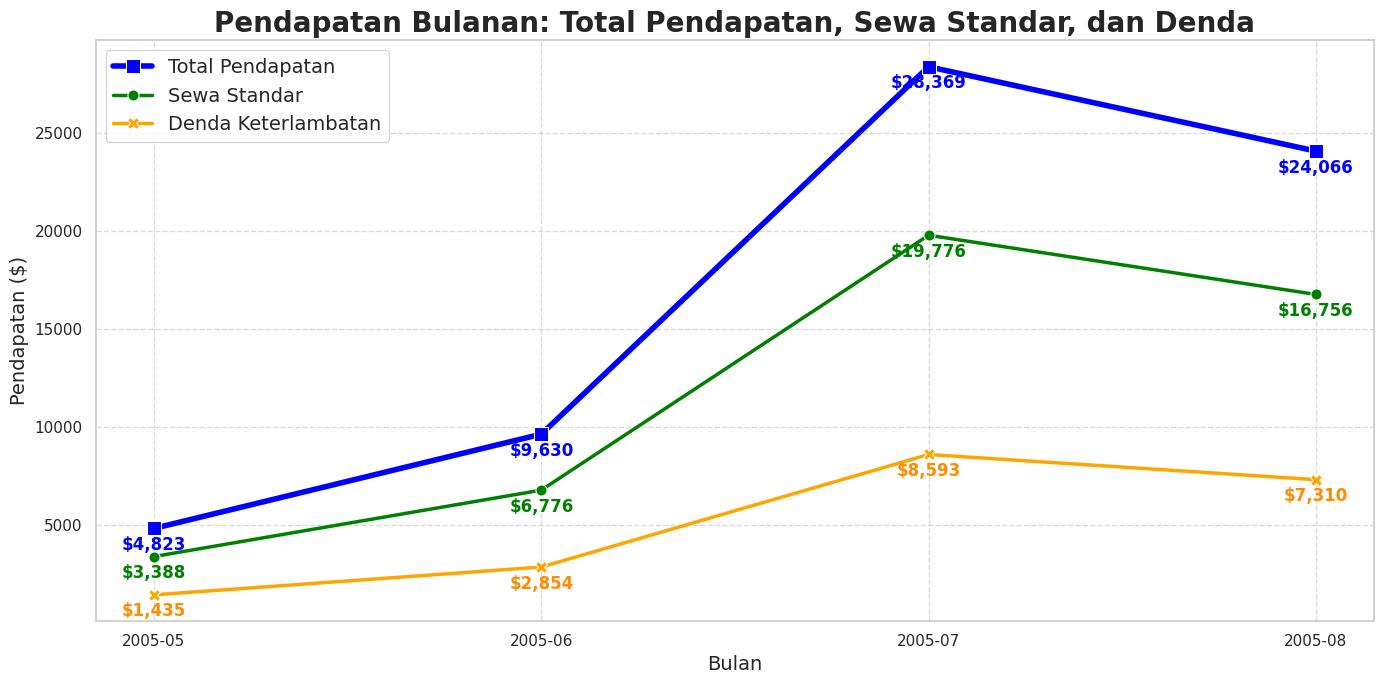

In [186]:
#Membaca data dari file CSV yang sudah di join di SQL
df = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/pendapatan_bulanan.csv")

#Mengubah kolom tanggal menjadi tipe datetime
df["Tanggal Transaksi"] = pd.to_datetime(df["Tanggal Transaksi"])

#Mengelompokkan data per Bulan-Tahun (Format: YYYY-MM) menggunakan .dt.to_period("M")
trend = df.groupby(df["Tanggal Transaksi"].dt.to_period("M")).agg({
    "Pendapatan Sewa Standar ($)": "sum",
    "Pendapatan Denda Keterlambatan ($)": "sum",
    "Total Pendapatan ($)": "sum"
}).reset_index()

#Mengubah tipe tanggal menjadi string untuk sumbu X grafik
trend["Tanggal Transaksi"] = trend["Tanggal Transaksi"].astype(str)

#Membuat Visualisasi Grafik
plt.figure(figsize=(14, 7))

#Garis 1: Total Pendapatan (Warna Biru)
sns.lineplot(
    data=trend, x="Tanggal Transaksi", y="Total Pendapatan ($)",
    marker="s", markersize=10, linewidth=4, color="blue", label="Total Pendapatan"
)

#Garis 2: Pendapatan Sewa Standar (Warna Hijau)
sns.lineplot(
    data=trend, x="Tanggal Transaksi", y="Pendapatan Sewa Standar ($)",
    marker="o", markersize=8, linewidth=2.5, color="green", label="Sewa Standar"
)

#Garis 3: Pendapatan Denda Keterlambatan (Warna Oranye)
sns.lineplot(
    data=trend, x="Tanggal Transaksi", y="Pendapatan Denda Keterlambatan ($)",
    marker="X", markersize=8, linewidth=2.5, color="orange", label="Denda Keterlambatan"
)

#Memberikan Label Angka (Data Label) di setiap titik plot
#Label untuk Total Pendapatan (Biru)
for x, y in zip(trend["Tanggal Transaksi"], trend["Total Pendapatan ($)"]):
    plt.text(x, y - 1100, f"${round(y):,}", ha="center", fontsize=12, color="blue", weight="bold")

#Label untuk Sewa Standar (Hijau)
for x, y in zip(trend["Tanggal Transaksi"], trend["Pendapatan Sewa Standar ($)"]):
    plt.text(x, y - 1100, f"${round(y):,}", ha="center", fontsize=12, color="green", weight="bold")

# Label untuk Denda (Oranye)
for x, y in zip(trend["Tanggal Transaksi"], trend["Pendapatan Denda Keterlambatan ($)"]):
    plt.text(x, y - 1100, f"${round(y):,}", ha="center", fontsize=12, color="darkorange", weight="bold")

#Mengatur Desain Grafik
plt.grid(linestyle="--", alpha=0.7)
plt.title("Pendapatan Bulanan: Total Pendapatan, Sewa Standar, dan Denda", fontsize=20, weight="bold")
plt.xlabel("Bulan", fontsize=14)
plt.ylabel("Pendapatan ($)", fontsize=14)
plt.legend(fontsize=14, loc="upper left")
plt.tight_layout()

#Menyimpan grafik
plt.savefig("Tren Pendapatan Bulanan.png", dpi=300, bbox_inches="tight")

#Menampilkan Grafik
plt.show()

1. Denda Keterlambatan Adalah "Pendapatan" Kedua Toko
*   Insight: Di setiap bulannya, nilai denda keterlambatan menyumbang sekitar 30-50% dari total pendapatan bulanan toko. Ini menunjukkan bahwa denda keterlambatan di toko Sakila dapat menjadi sumber pendapatan pasif (*secondary revenue stream*). Pelanggan di toko ini memiliki kecenderungan tinggi untuk telat mengembalikan DVD.
*   Rekomendasi: Karena kontribusi denda sangat besar, manajemen tidak perlu memperketat durasi sewa (misal dengan buru-buru menghubungi pelanggan untuk mengembalikan DVD), karena "kelalaian" pelanggan terbukti menguntungkan secara finansial bagi toko selama aset kaset pada akhirnya tetap kembali.

2. Karakteristik Siklus Pendapatan (*Seasonality*)
*   Insight: Grafik menunjukkan tren kenaikan yang sangat tajam di bulan Juli dan Agustus dengan total pendapatan lebih dari $20.000. Bulan Juli dan Agustus merupakan *peak season* toko ini. Kemungkinan besar ini dipengaruhi oleh faktor eksternal seperti liburan musim panas (summer break), di mana orang-orang memiliki lebih banyak waktu luang untuk menyewa dan menonton film di rumah.
*   Rekomendasi: Mengingat bulan Juli-Agustus adalah *peak season*, toko harus melakukan perawatan kaset dan memperbanyak stok film populer pada bulan Mei atau Juni di tahun berikutnya agar tidak kehilangan potensi pasar saat permintaan melonjak.

##2. Performa Penjualan Setiap Toko (boxplot-matplotlib)

/tmp/ipykernel_783/272224632.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


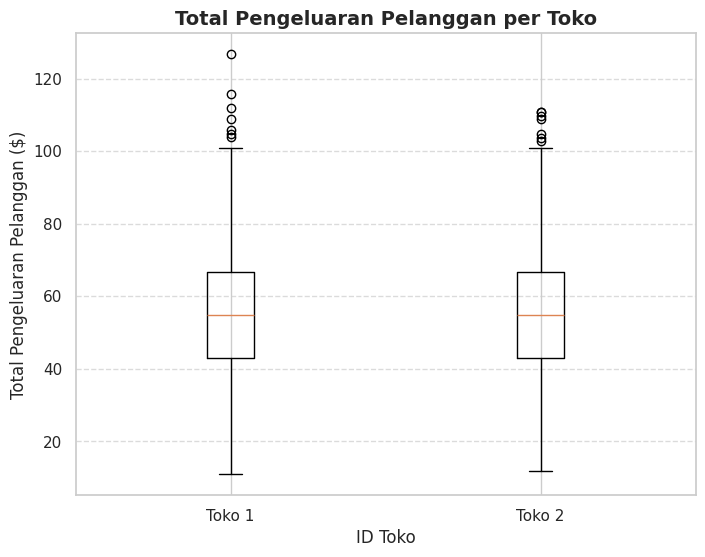

In [187]:
#Membaca data yang sudah di join di SQL
df = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/performa_penjualan_toko.csv")

#Menyiapkan list kosong untuk menampung data
store_data = []

#Mengambil daftar ID Toko yang unik secara urut [1, 2]
unique_stores = sorted(df["ID Toko"].unique())

#Looping untuk memisahkan total belanja pelanggan berdasarkan ID Toko masing-masing
for s in unique_stores:
    store_data.append(df[df["ID Toko"] == s]["Total Pengeluaran Pelanggan ($)"])

#Mengatur ukuran kanvas grafik
plt.figure(figsize=(8, 6))

#Membuat Boxplot Matplotlib
plt.boxplot(
    store_data,
    labels=[f"Toko {s}" for s in unique_stores] # Memberikan label "Store 1" dan "Store 2"
)

#Mengatur Desain Grafik
plt.title("Total Pengeluaran Pelanggan per Toko", fontsize=14, weight="bold")
plt.ylabel("Total Pengeluaran Pelanggan ($)", fontsize=12)
plt.xlabel("ID Toko", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7) # Grid putus-putus horizontal

#Menyimpan grafik
plt.savefig("Total Pengeluaran Pelanggan per Store.png", dpi=300, bbox_inches="tight")

# 10. Menampilkan Grafik
plt.show()

1. Membaca Kotak (Kuartil 1 sampai Kuartil 3)
*   Batas bawah kedua kotak dimulai dari angka sekitar 40 dollar, dan batas atasnya berakhir di kisaran 70 dollar. Artinya, sebanyak 50% dari total pelanggan di kedua toko tersebut memiliki rentang pengeluaran akumulatif yang sama, yaitu antara 40 dollar hingga 70 dollar. Ini menunjukkan pengeluaran pelanggan utama di kedua toko sangat mirip.

2. Membaca Garis Oranye di Tengah Kotak (Median)
*   Garis nilai tengah (median) di kedua toko berada di posisi yang hampir sejajar, yaitu di angka sekitar 50-an dollar. Secara statistik nilai tengah, performa penjualan dan kontribusi dari pelanggan reguler di Toko 1 dan Toko 2 adalah seimbang.

3. Membaca Titik-Titik di Paling Atas (Outliers)
*   dengan melihat titik-titik hitam yang berada di atas batas garis antena tertinggi. Di Toko 1, ada titik yang mencapai angka sekitar 125 dollar. Di Toko 2, titik paling atasnya hanya sampai di kisaran angka 110 dollar. Artinya, Toko 1 memiliki nilai transaksi ekstrem per pelanggan yang lebih tinggi dibandingkan Toko 2.
*   Rekomendasi: Karena Toko 1 punya pelanggan yang berani keluar uang paling banyak (sampai 125 dollar). Toko bisa membuatkan program khusus seperti member VIP, diskon ulang tahun, atau hadiah kecil supaya mereka tidak pindah ke toko kompetitor.
*   Rekomendasi: Membuat promo paket bundling (misal: "Sewa 3 film sekaligus mendapat potongan harga berapa persen") di Toko 2, agar pelanggan menengah di sana terpancing untuk mengeluarkan uang lebih banyak.


##3. Total Pendapatan per Genre (Horizontal Bar Chart-Matplotlib)

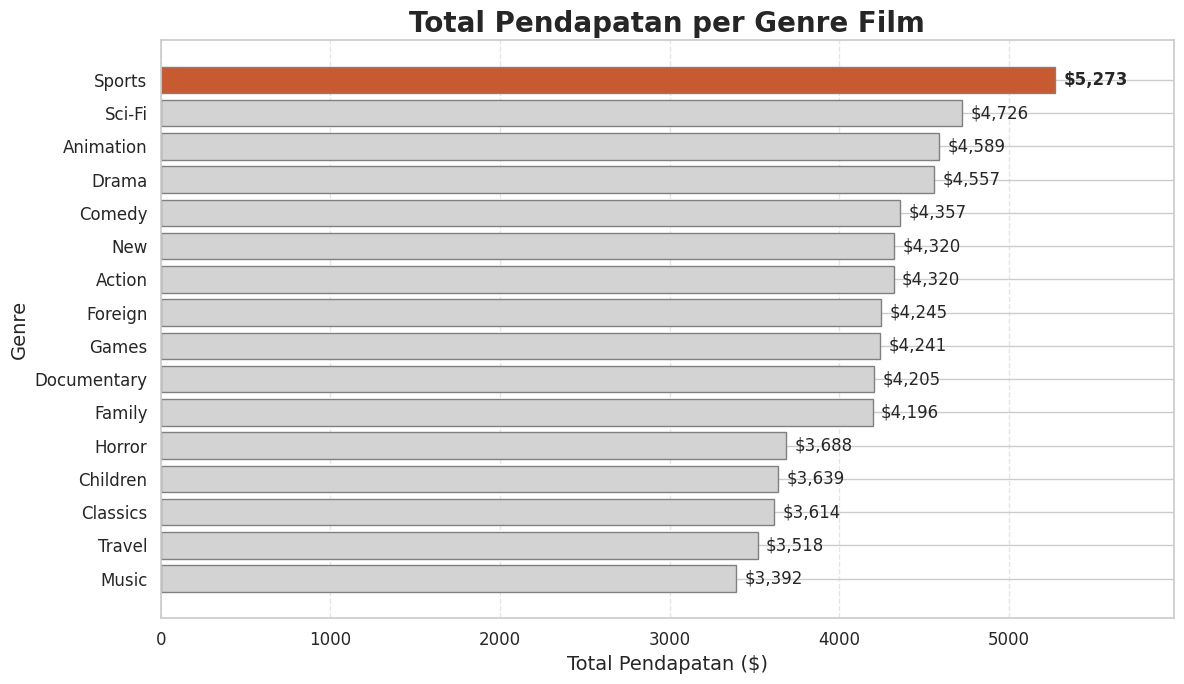

In [188]:
#Membaca data yang sudah di join di SQL
df = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/total_transaksi_dan_pendapatan_per_genre.csv")

#Urutkan data dari pendapatan terkecil ke terbesar (ascending=True)
#Supaya saat digambar menjadi horizontal, urutan tertinggi otomatis berada di paling atas
df_pendapatan = df.sort_values(by="Total Pendapatan ($)", ascending=True)

#Membuat logika warna spotlight
warna_pendapatan = []
for genre in df_pendapatan["Genre"]:
    if genre in ["Sports"]:
        warna_pendapatan.append("#C85A32")  # Warna jingga kemerahan mencolok (Spotlight)
    else:
        warna_pendapatan.append("#D3D3D3")  # Warna abu-abu tenang untuk genre lainnya

#Mengatur ukuran kanvas
plt.figure(figsize=(12, 7))

#Membuat Horizontal Bar Chart menggunakan Matplotlib
bars = plt.barh(
    df_pendapatan["Genre"],
    df_pendapatan["Total Pendapatan ($)"],
    color=warna_pendapatan,
    edgecolor="grey"
)

#Menambahkan label angka pendapatan tepat di ujung kanan setiap bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,                        # Jarak teks (koordinat X) sedikit di kanan batang
        bar.get_y() + bar.get_height()/2,  # Posisi teks (koordinat Y) tepat di tengah batang
        f"${int(width):,}",                # Format angka uang dibulatkan
        ha="left", va="center", fontsize=12,
        weight="bold" if bar.get_facecolor() == (200/255, 90/255, 50/255, 1.0) else "normal"
    )

#Mengatur Desain Grafik
plt.title("Total Pendapatan per Genre Film", fontsize=20, weight="bold")
plt.xlabel("Total Pendapatan ($)", fontsize=14)
plt.ylabel("Genre", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#Memberikan ruang tambahan di sisi kanan grafik agar label teks angka tidak terpotong
plt.xlim(0, df_pendapatan["Total Pendapatan ($)"].max() + 700)

#Menambahkan garis bantu (grid) putus-putus tegak lurus di sumbu X
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

#Menyimpan grafik
plt.savefig("Total Pendapatan per Genre Film.png", dpi=300, bbox_inches="tight")

#Menampilkan Hasil Grafik
plt.show()

1. Dominasi Genre Sports
*   Insight: Genre Sports kokoh berada di peringkat pertama dengan total pendapatan mencapai 5,273 dollar. Genre Sports adalah produk paling populer dan menjadi penggerak utama bagi total pendapatan toko film Sakila.
*   Rekomendasi: Maksimalisasi Potensi Produk Unggulan (Fokus pada Sports). Karena genre Sports penjualannya paling tinggi, manajemen harus memastikan ketersediaan stok film olahraga selalu diperbarui (up-to-date) dengan judul-judul box office terbaru. Letakkan kaset-kaset genre Sports di rak bagian depan toko.

2. Kelompok Menengah Cenderung Stabil
*   Insight: Jika diperhatikan pada batang-batang berwarna abu-abu, rentang pendapatan dari genre Sci-Fi hingga Family memiliki selisih angka yang sangat tipis dan cenderung stabil di angka 4,200 - 4,500 dollar. Kelompok ini adalah kategori film yang memiliki pasar yang stabil dan konsisten.
*   Rekomendasi: Strategi Promosi Silang (Cross-Promotion). Gunakan popularitas film Sports untuk mengangkat genre menengah. Misalnya, buat promo paket bundling: "Setiap sewa 1 Film Sports, dapatkan diskon potongan harga untuk sewa film kategori Action atau Drama."

3. Kategori dengan Performa Terendah
*   Insight: Genre Music berada di posisi paling bawah dengan pendapatan sebesar 3,392 dollar, disusul oleh genre Travel dan Classics. Ketiga genre ini kurang diminati oleh basis pelanggan toko Sakila, sehingga perputaran uang pada kategori ini berjalan lambat.
*   Rekomendasi: Evaluasi Stok dan Efisiensi Anggaran (Fokus pada Music & Travel). Kurangi alokasi anggaran untuk membeli atau menyetok film baru di genre Music, Travel, dan Classics. Membatasi anggaran pada genre yang sepi peminat ini akan membantu toko menghemat biaya operasional, lalu mengalihkan dananya untuk menambah variasi di genre Sports atau Sci-Fi yang terbukti mendatangkan untung lebih besar.

##4. Durasi Rental Film per Rating (Boxplot-Seaborn)

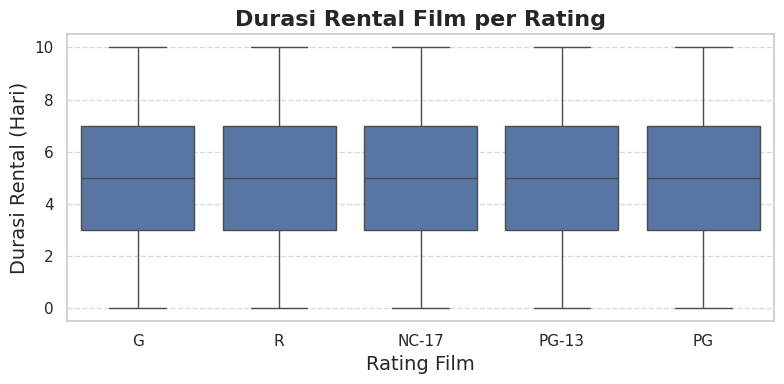

In [189]:
#Membaca data yang sudah di join di SQL
df = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/durasi_rental_rating.csv")

#boxplot seaborn durasi rental film per kategori
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="rating_film",
    y="durasi_rental_hari"
)
plt.title("Durasi Rental Film per Rating", fontsize=16, weight="bold")
plt.xlabel("Rating Film", fontsize=14)
plt.ylabel("Durasi Rental (Hari)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

#Menyimpan grafik
plt.savefig("Durasi Rental Film per Rating.png", dpi=300, bbox_inches="tight")

plt.show()

*   Insight: Grafik menunjukkan bahwa distribusi durasi rental pada seluruh rating film (G, PG, PG-13, R, dan NC-17) relatif serupa. Median durasi rental berada di sekitar 5 hari dengan rentang penyebaran yang hampir sama pada setiap kategori rating. Hal ini mengindikasikan bahwa rating film tidak memiliki pengaruh yang signifikan terhadap lamanya pelanggan menyimpan film sebelum dikembalikan. Dengan kata lain, pelanggan cenderung mengembalikan film dalam jangka waktu yang hampir sama terlepas dari rating film yang disewa.
*   Rekomendasi: Manajemen tidak perlu menerapkan kebijakan durasi sewa yang berbeda berdasarkan rating film karena perilaku pengembalian pelanggan terlihat cukup konsisten pada seluruh kategori rating. Fokus perusahaan dapat dialihkan pada faktor lain yang berpotensi lebih memengaruhi durasi rental, seperti popularitas film, kategori genre, atau program promosi tertentu.

##5. Perbandingan Revenue Berdasarkan Rating Film (Pie Chart - Matplotlib)

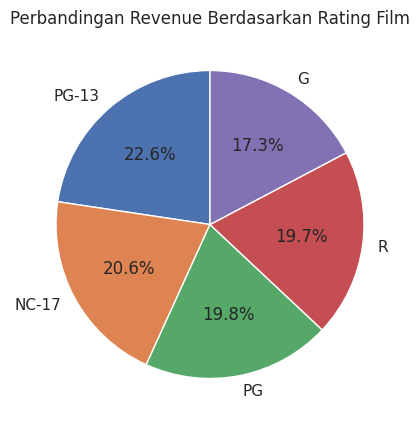

In [190]:
#Membaca data yang sudah di join di SQL
df = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/revenue_rating_film.csv")

#Pie Chart Matplotlib
plt.figure(figsize=(5,5))

plt.pie(
    df["total_revenue"],
    labels=df["rating_film"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Perbandingan Revenue Berdasarkan Rating Film")

#Menyimpan grafik
plt.savefig("Perbandingan Revenue Berdasarkan Rating Film.png", dpi=300, bbox_inches="tight")

plt.show()

*   Insight: Grafik menunjukkan bahwa kontribusi pendapatan dari setiap rating film relatif seimbang. Rating PG-13 memberikan kontribusi revenue terbesar sebesar 22,6%, diikuti oleh NC-17 sebesar 20,6%, PG sebesar 19,8%, R sebesar 19,7%, dan G sebesar 17,3%. Perbedaan kontribusi antar rating tidak terlalu jauh, yang menunjukkan bahwa pendapatan perusahaan tidak bergantung pada satu kategori rating tertentu. Hal ini mencerminkan keberagaman preferensi pelanggan dalam memilih film dari berbagai rating.
*   Rekomendasi:
Perusahaan sebaiknya mempertahankan ketersediaan koleksi film pada seluruh kategori rating karena masing-masing memberikan kontribusi pendapatan yang cukup signifikan. Selain itu, promosi dapat difokuskan pada rating PG-13 yang memiliki kontribusi revenue tertinggi untuk meningkatkan pendapatan, tanpa mengurangi perhatian terhadap kategori rating lainnya yang juga berperan penting dalam menghasilkan revenue perusahaan.

##6. Basis Pelanggan Berdasarkan Negara/Kota (Bar Chart-Seaborn)

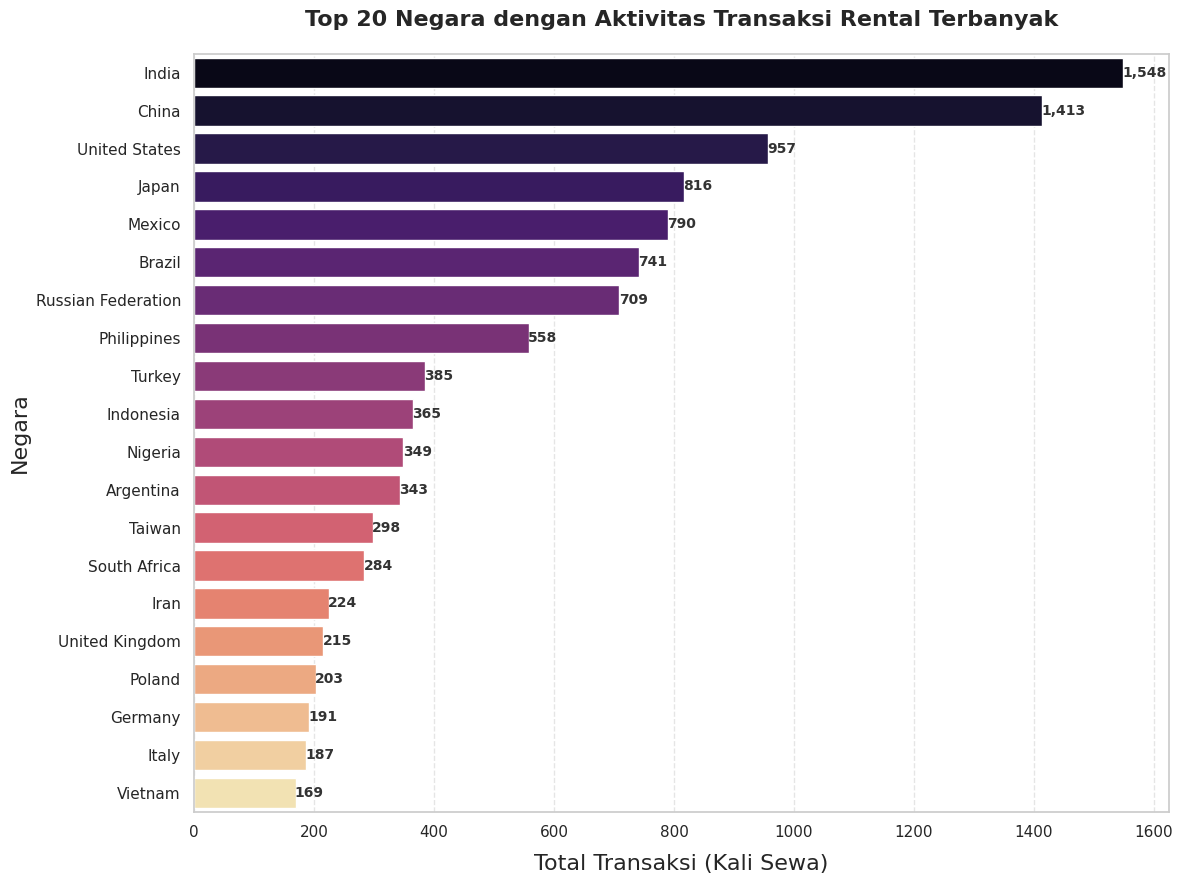

In [191]:
sns.set_theme(style="whitegrid")

#Membaca file yang sudah di join di SQL
df_transaksi = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/transaction_country.csv")

# Ukuran kanvas ditinggikan (dari 6 menjadi 9) agar 20 nama negara tidak saling berdesakan
plt.figure(figsize=(12, 9))

ax1 = sns.barplot(
    x="Total Transaksi",
    y="Negara",
    data=df_transaksi,
    hue="Negara",
    palette="magma",
    legend=False,
)

# Menambahkan anotasi data label angka riil di ujung setiap batang grafik
for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.text(
            width - 1,  # Jarak teks dari ujung batang
            p.get_y() + p.get_height() / 2,
            f"{int(width):,}",  # Format ribuan
            ha="left",
            va="center",
            fontweight="bold",
            fontsize=10,
            color="#333333",
        )

plt.title(
    "Top 20 Negara dengan Aktivitas Transaksi Rental Terbanyak",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Total Transaksi (Kali Sewa)", fontsize=16, labelpad=10)
plt.ylabel("Negara", fontsize=16)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

#Menyimpan grafik
plt.savefig("Top 20 Negara dengan Aktivitas Transaksi Rental Terbanyak.png", dpi=300, bbox_inches="tight")

plt.show()

1.   Insight
*   India menjadi negara dengan jumlah transaksi dan pendapatan tertinggi dibandingkan negara lainnya.
*   Kontribusi pendapatan yang besar menunjukkan bahwa pasar India memiliki tingkat permintaan dan loyalitas pelanggan yang tinggi.
*   Perusahaan dapat memprioritaskan strategi pemasaran dan program loyalitas di India untuk mempertahankan pertumbuhan pendapatan.

2.   Rekomendasi
*   Alokasikan anggaran pemasaran lebih besar pada negara dengan kontribusi transaksi dan pendapatan tertinggi.
*   Kembangkan promosi dan program loyalitas yang disesuaikan dengan karakteristik pelanggan di negara tersebut.
*   Pantau tren transaksi per negara secara berkala untuk mengidentifikasi peluang ekspansi pasar baru.

##7. Klasifikasi Customer Berdasarkan Total Spend

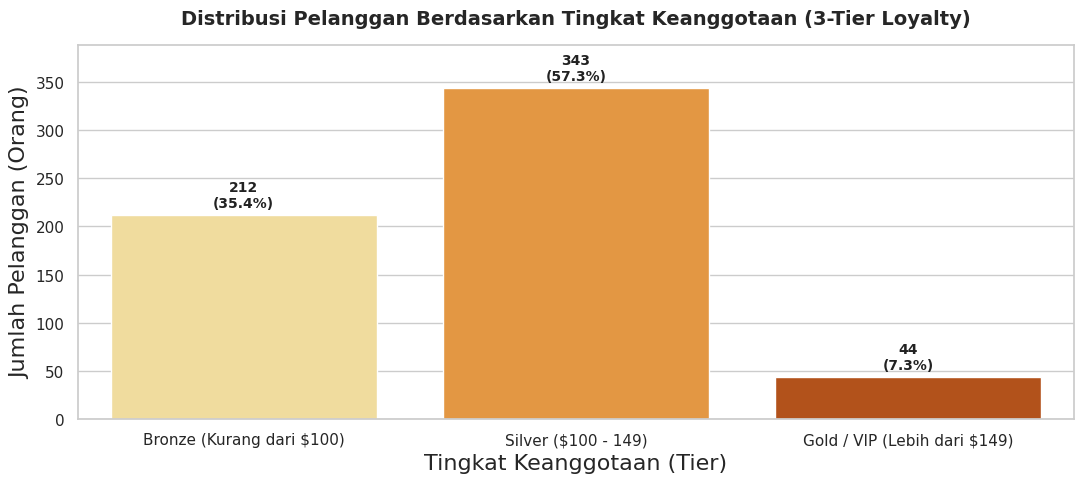

In [192]:
#Membaca data yang sudah di join di SQL
df_revenue = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/klasifikasi_pelanggan.csv")

#Mengklasifikasikan pelanggan berdasarkan total spending
def segment_ke_3_tier(spending):
    if spending < 100:
        return "Bronze (Kurang dari $100)"
    elif spending <= 149:
        return "Silver ($100 - 149)"
    else:
        return "Gold / VIP (Lebih dari $149)"

df_revenue["tingkat_loyalty"] = df_revenue["total_spending"].apply(
    segment_ke_3_tier
)

tier_order = [
    "Bronze (Kurang dari $100)",
    "Silver ($100 - 149)",
    "Gold / VIP (Lebih dari $149)",
]

plt.figure(figsize=(11, 5))
ax2 = sns.countplot(
    x="tingkat_loyalty",
    data=df_revenue,
    order=tier_order,
    hue="tingkat_loyalty",
    palette="YlOrBr",
    legend=False,
)

total_cust = len(df_revenue)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_cust) * 100
        ax2.text(
            p.get_x() + p.get_width() / 2.0,
            height + 5,
            f"{int(height)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
            color="#222222",
        )

plt.title(
    "Distribusi Pelanggan Berdasarkan Tingkat Keanggotaan (3-Tier Loyalty)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tingkat Keanggotaan (Tier)", fontsize=16)
plt.ylabel("Jumlah Pelanggan (Orang)", fontsize=16)
plt.ylim(0, max(df_revenue["tingkat_loyalty"].value_counts()) + 45)
plt.tight_layout()

#Menyimpan grafik
plt.savefig("Distribusi Pelanggan Berdasarkan Tingkat Keanggotaan.png", dpi=300, bbox_inches="tight")

plt.show()

1.   Insight
*   Mayoritas pelanggan berada pada segmen Silver sehingga segmen ini menjadi kontributor utama jumlah transaksi.
*   Pelanggan Gold memiliki nilai transaksi rata-rata yang lebih tinggi dibandingkan segmen lainnya meskipun jumlahnya lebih sedikit.
2.   Rekomendasi
*   Dorong pelanggan Silver naik ke segmen Gold dengan sistem poin, diskon bertingkat, atau bonus transaksi.
*   Lakukan kampanye personalisasi berdasarkan segmen pelanggan untuk meningkatkan frekuensi penyewaan dan nilai transaksi.

##8. Hubungan antara "Durasi Keterlambatan Pengembalian" vs "Total Denda yang Dibayar" (Scatter Plot-Matplotlib)

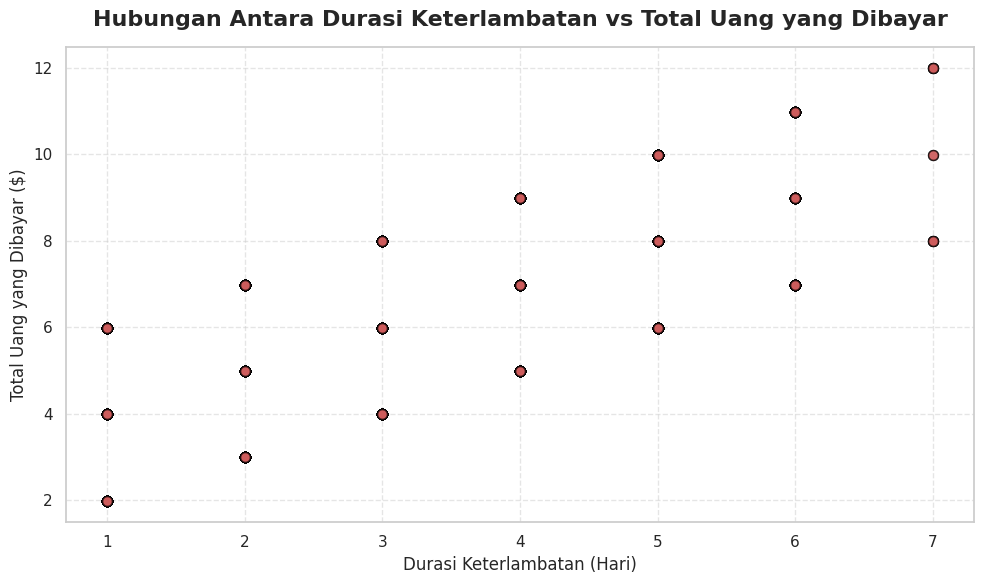

In [193]:
#Membaca file yang sudah di join di SQL
df_denda = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/hubungan_durasi_keterlambatan_dan_denda.csv")

#Menghitung hari keterlambatan
df_denda["hari_keterlambatan"] = df_denda["durasi_sewa_aktual"] - df_denda["jatah_durasi_film"]

#Filter: Hanya ambil data yang memiliki keterlambatan (hari_keterlambatan > 0)
df_telat = df_denda[df_denda["hari_keterlambatan"] > 0]

#Membuat Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df_telat["hari_keterlambatan"], # Sumbu X
    df_telat["denda_yang_dibayar"], # Sumbu Y
    alpha=0.4,
    color="#CD5C5C",
    edgecolors="black",
    s=50                            # Ukuran titik
)

#Mengatur Desain Grafik
plt.title("Hubungan Antara Durasi Keterlambatan vs Total Uang yang Dibayar", fontsize=16, weight="bold", pad=15)
plt.xlabel("Durasi Keterlambatan (Hari)", fontsize=12)
plt.ylabel("Total Uang yang Dibayar ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

#Menyimpan grafik
plt.savefig("Hubungan Antara Durasi Keterlambatan vs Total Uang yang Dibayar.png", dpi=300, bbox_inches="tight")

#Menampilkan Grafik
plt.show()

1. Korelasi Positif
*   Insight: Titik-titik data bergerak membentuk arah diagonal naik ke kanan atas membuktikan adanya korelasi positif yang linear. Artinya, semakin lama jumlah hari keterlambatan pelanggan dalam mengembalikan kaset (sumbu X), maka total uang yang harus dibayarkan di kasir (sumbu Y) akan semakin membengkak secara konsisten.
*   Rekomendasi: Mengadakan Sistem Peringatan Pengembalian. Karena biaya denda terus membengkak secara linear (kasihan pelanggannya jika telat terlalu lama), toko bisa membuat sistem EMAIL otomatis. Jika kaset belum kembali di H-1 batas durasi sewa, pelanggan akan dikirimi pengingat. Ini penting untuk menjaga loyalitas agar pelanggan tidak "kapok" menyewa akibat akumulasi denda yang terlalu besar.

2. Mengapa titik-titiknya tidak menumpuk di satu garis saja, melainkan terbagi menjadi 3 jalur terpisah?
*   Ini terjadi karena Toko Sakila memiliki 3 variasi harga sewa dasar yaitu 0.99 dollar (sebaran di jalur bawah), 2.99 dollar (sebaran di jalur tengah), dan 4.99 dollar (sebaran di jalur atas). Kesamaan kemiringan (kemiringan sudut) dari ketiga garis ini membuktikan bahwa tarif denda per hari yang diterapkan toko adalah sama rata (konstan) untuk semua jenis film (di database Sakila, tarif denda umumnya dipatok 1 dollar per hari keterlambatan).
*   Rekomendasi: Pengetatan Aturan untuk Jalur Atas (film seharga 4.99 dollar). Pelanggan di jalur paling atas yang telat hingga 4-5 hari harus membayar total biaya hingga 10-12 dollar. Angka ini sudah mendekati harga yang harus dibayar kalau kaset rusak atau hilang (replacement cost). Manajemen disarankan memberikan batas maksimal denda (capped penalty) agar pelanggan tidak memilih untuk membawa kabur kasetnya karena denda yang terlalu mahal.

##9. Performa Staf Berdasarkan Total Pendapatan (Bar Charts-Matplotlib)

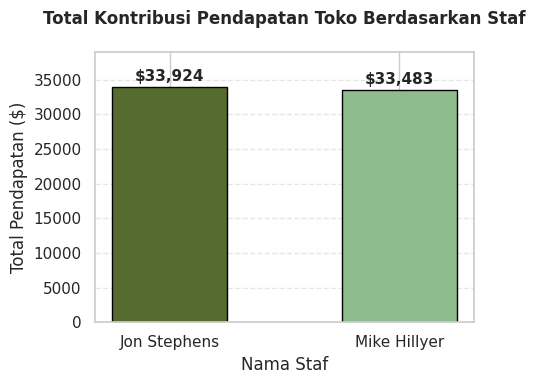

In [194]:
#Membaca data yang sudah di join di
df_staf = pd.read_csv("https://raw.githubusercontent.com/dewitrilestari/BLKPP-DIY-VS-CODE/refs/heads/main/DVD%20Rental/DVD%20Join/performa_staff.csv")

#Mengatur ukuran kanvas grafik
plt.figure(figsize=(5, 4))

#Membuat Bar Chart
colors = ["#556B2F", "#8FBC8F"]
bars = plt.bar(
    df_staf["nama_staf"],
    df_staf["total_pendapatan"],
    color=colors,
    edgecolor="black",
    width=0.5
)

#Menambahkan label nominal uang di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 500, # Jarak teks di atas batang
        f"${yval:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

#Mengatur Desain Grafik
plt.title("Total Kontribusi Pendapatan Toko Berdasarkan Staf", fontsize=12, weight="bold", pad=20)
plt.xlabel("Nama Staf", fontsize=12)
plt.ylabel("Total Pendapatan ($)", fontsize=12)
plt.ylim(0, max(df_staf["total_pendapatan"]) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

#Menyimpan grafik
plt.savefig("Performa Staf.png", dpi=300, bbox_inches="tight")

#Menampilkan grafik
plt.show()

1. Keseimbangan Beban Kerja dan Performa
*   Insight: Grafik menunjukkan bahwa kontribusi pendapatan antara Jon Stephens dan Mike Hillyer hampir sama yaitu diangka 33 ribu dollar. Hal ini mengindikasikan adanya pembagian beban kerja yang sangat adil dan merata di antara para staf. Tidak ada ketimpangan di mana satu staf bekerja jauh lebih keras daripada staf lainnya. Siapa pun staf yang berjaga di meja depan, performa transaksi yang dihasilkan tetap stabil dan konsisten.
*   Rekomendasi: Penerapan Bonus Berbasis Tim. Karena selisihnya tidak signifikan, manajemen sebaiknya tidak memberikan bonus individu yang dapat memicu kecemburuan sosial. Lebih baik memberikan insentif kelompok karena kedua staf terbukti telah bekerja sama dengan sangat solid dalam menjaga kestabilan pendapatan toko.